# 6 — Switching to numpyro NUTS

Since v2.5, ``eddy`` ships a JAX-backed model and supports two MCMC
backends for :class:`~eddy.rotationmap.rotationmap.fit_map`:

- ``mcmc='emcee'`` — the historical default. Affine-invariant ensemble
  sampler with no gradient information; needs many walkers to explore
  high-dimensional posteriors.
- ``mcmc='numpyro'`` — opt-in NUTS sampler that uses the JAX gradient of
  the same likelihood. Far more sample-efficient at high dimensions
  (typically ``200`` post-warmup samples reach a posterior resolution
  comparable to emcee with ``32 walkers × 1000 samples``), at the cost
  of higher per-sample wall time.

Both backends agree to within sampling noise on the standard 9-parameter
HD163296 3D fit (see ``REFACTORING_PLAN.md §5.1b``); pick whichever
suits the problem.

This short tutorial demonstrates the numpyro path on the same data used
in `Tutorial 2 <tutorial_2.html>`_.


## Setup

The data files are the same as Tutorial 2 — download them if you
haven't already.


In [1]:
import os
if not os.path.exists('HD163296_CO_v0.fits'):
    !wget -O HD163296_CO_v0.fits -q https://dataverse.harvard.edu/api/access/datafile/:persistentId?persistentId=doi:10.7910/DVN/C2ZUNO/AWCSZR
if not os.path.exists('HD163296_CO_dv0.fits'):
    !wget -O HD163296_CO_dv0.fits -q https://dataverse.harvard.edu/api/access/datafile/:persistentId?persistentId=doi:10.7910/DVN/C2ZUNO/NGOW49


In [2]:
from eddy import rotationmap

cube = rotationmap(path='HD163296_CO_v0.fits',
                   uncertainty='HD163296_CO_dv0.fits',
                   FOV=8.0, downsample=4)


## Tightening unbounded priors

NUTS samples in an *unconstrained* parameter space and uses a bijective
transform to map back to the prior support. For ``Uniform(lo, hi)`` the
transform is well-conditioned only when both bounds are finite; an
improper prior such as ``r_taper ∈ (0, ∞)`` (the default) maps to an
unbounded ``log`` transform whose curvature is poor at large values, and
NUTS trees blow up to thousands of leapfrog steps per iteration.

emcee tolerates unbounded uniforms transparently because it only
inspects the bounds, but for the numpyro path it pays to tighten any
``inf`` upper or lower bound to a finite value larger than the
physically interesting range. For HD163296, ``r_taper`` larger than the
field of view is irrelevant, so a generous ceiling of 50″ works:


In [3]:
cube.set_prior('r_taper', [0.0, 50.0], 'flat')


## Setting up the fit

The free-parameter dictionary, fixed parameters, and ``p0`` are
identical to the 9-parameter 3D fit in Tutorial 2. Only the call to
``fit_map`` changes.


In [4]:
params = {}
params['x0'] = 0
params['y0'] = 1
params['PA'] = 2
params['mstar'] = 3
params['vlsr'] = 4
params['z0'] = 5
params['psi'] = 6
params['r_taper'] = 7
params['q_taper'] = 8

params['inc'] = 46.7
params['dist'] = 101.0
params['r_min'] = 2.0 * cube.bmaj

p0 = [0.0, 0.0, 312., 2.0, 5.7e3, 0.25, 1.0, 3.0, 2.0]


## Running the fit

The MCMC backend is selected with the ``mcmc=`` keyword. The legacy
walker/burnin/step kwargs map onto numpyro's ``num_chains`` /
``num_warmup`` / ``num_samples`` internally, so existing scripts can
switch backends by changing one keyword:

==================  =========================
``fit_map`` kwarg   numpyro equivalent
==================  =========================
``nwalkers``        ``num_chains``
``nburnin``         ``num_warmup``
``nsteps``          ``num_samples``
==================  =========================

NUTS additionally accepts a few sampler-specific kwargs through
``mcmc_kwargs``:

- ``seed`` — PRNG key seed (default ``0``).
- ``progress`` — show a progress bar (default ``True``).
- ``max_tree_depth`` — cap the doubling tree depth. Default is 10
  (≤1024 leapfrog steps per NUTS iteration). For typical
  ``rotationmap`` fits, a value of **6** (≤64 leapfrog steps) is a
  good default — it cuts wall time roughly in half versus the
  numpyro default at the cost of slightly less efficient exploration
  of strongly-correlated directions. Bump back up to ``8`` (≤256
  steps) if you observe poor mixing or many divergent transitions.
- ``chain_method`` — passed through to
  :class:`numpyro.infer.MCMC`. Default ``'sequential'``. Note that
  ``'vectorized'`` does **not** help in practice for ``fit_map``-style
  fits: NUTS' adaptive tree length is per-chain, so vmap'd chains
  must all run to the longest tree, cancelling the speedup.

Single-chain NUTS with 500 warmup + 500 samples is a reasonable
starting budget for a 9-parameter fit. The full run takes about four
minutes on a modern CPU with ``max_tree_depth=6`` and is dominated by
JAX compilation and the warmup adaptation.


W0513 09:17:29.631477 15671963 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


Assuming:
	p0 = [x0, y0, PA, mstar, vlsr, z0, psi, r_taper, q_taper].


Optimized starting positions:
	p0 = ['-1.39e-02', '-3.35e-02', '3.12e+02', '1.93e+00', '5.70e+03', '2.34e-01', '1.66e+00', '3.30e+00', '1.97e+00']


  0%|          | 0/1000 [00:00<?, ?it/s]

warmup:   5%|▌         | 50/1000 [00:07<02:24,  6.56it/s, 63 steps of size 6.80e-05. acc. prob=0.70]

...


/Users/richardteague/miniconda3/lib/python3.13/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


/Users/richardteague/miniconda3/lib/python3.13/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges
/Users/richardteague/miniconda3/lib/python3.13/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges
/Users/richardteague/miniconda3/lib/python3.13/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


/Users/richardteague/miniconda3/lib/python3.13/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


/Users/richardteague/miniconda3/lib/python3.13/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges
/Users/richardteague/miniconda3/lib/python3.13/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges
/Users/richardteague/miniconda3/lib/python3.13/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


/Users/richardteague/miniconda3/lib/python3.13/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


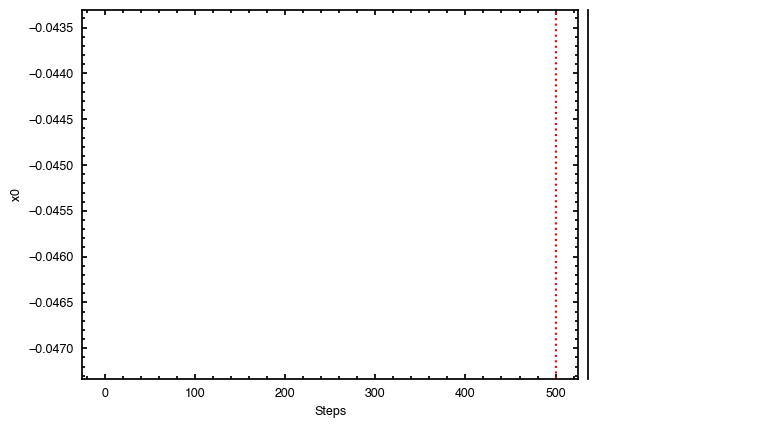

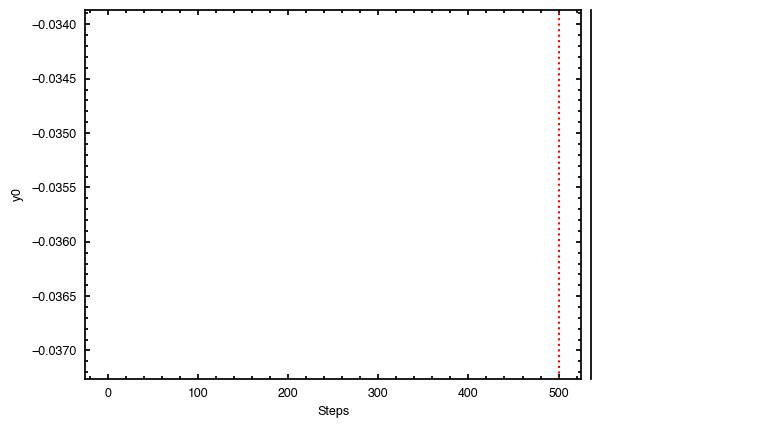

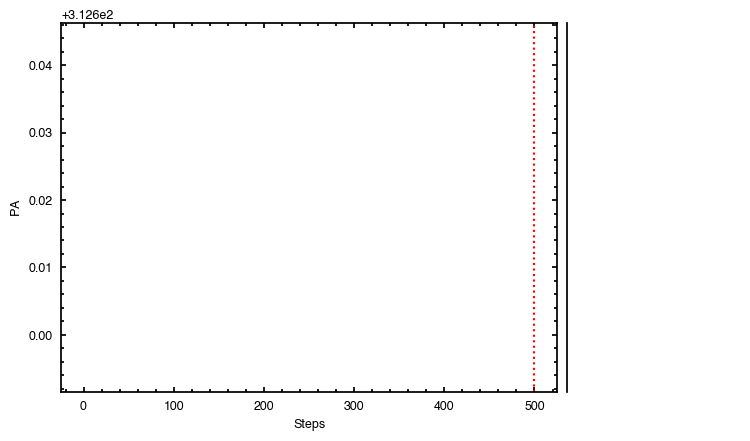

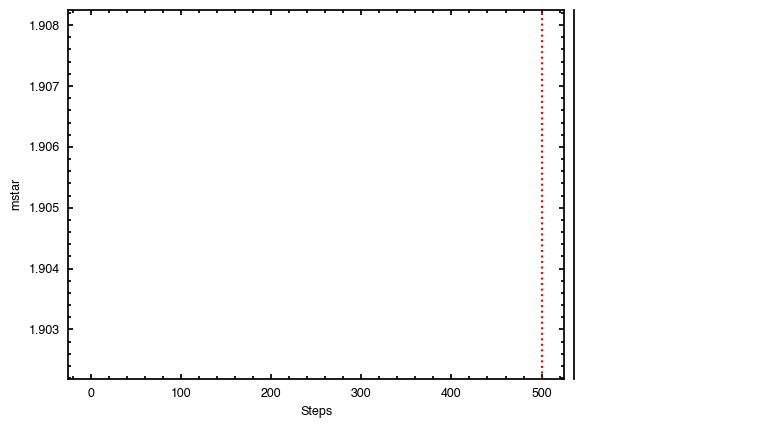

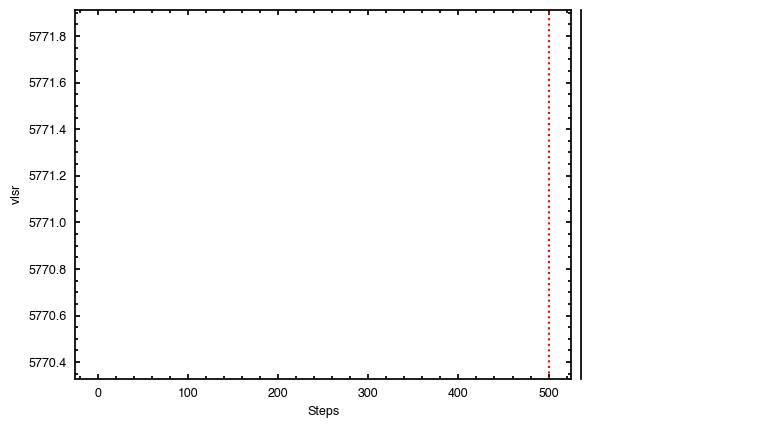

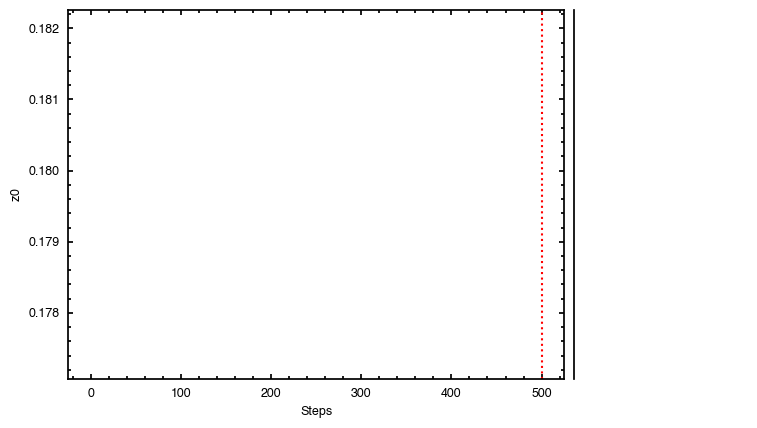

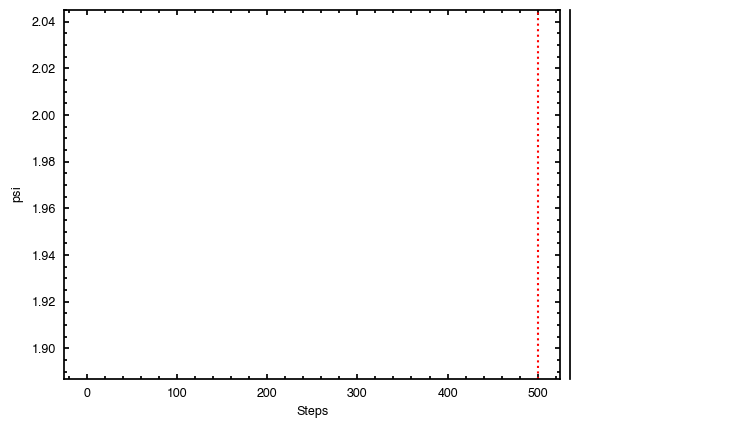

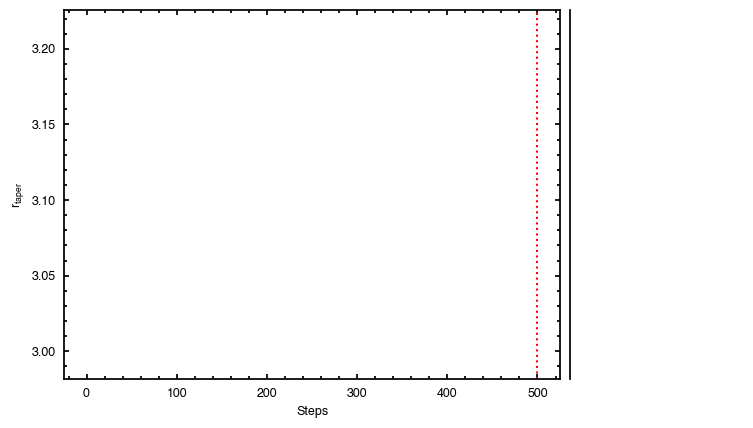

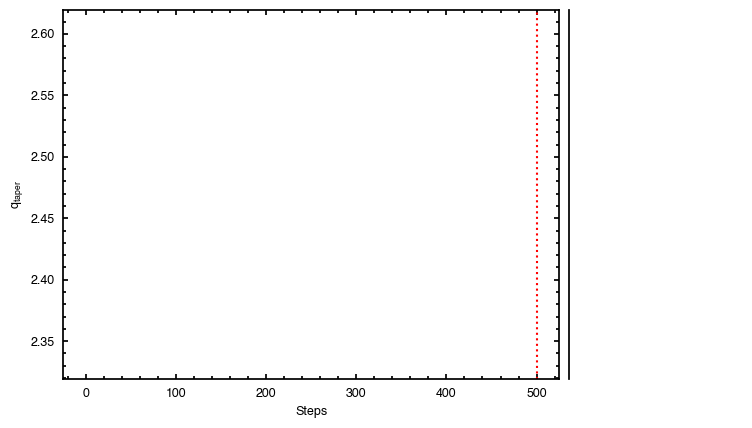

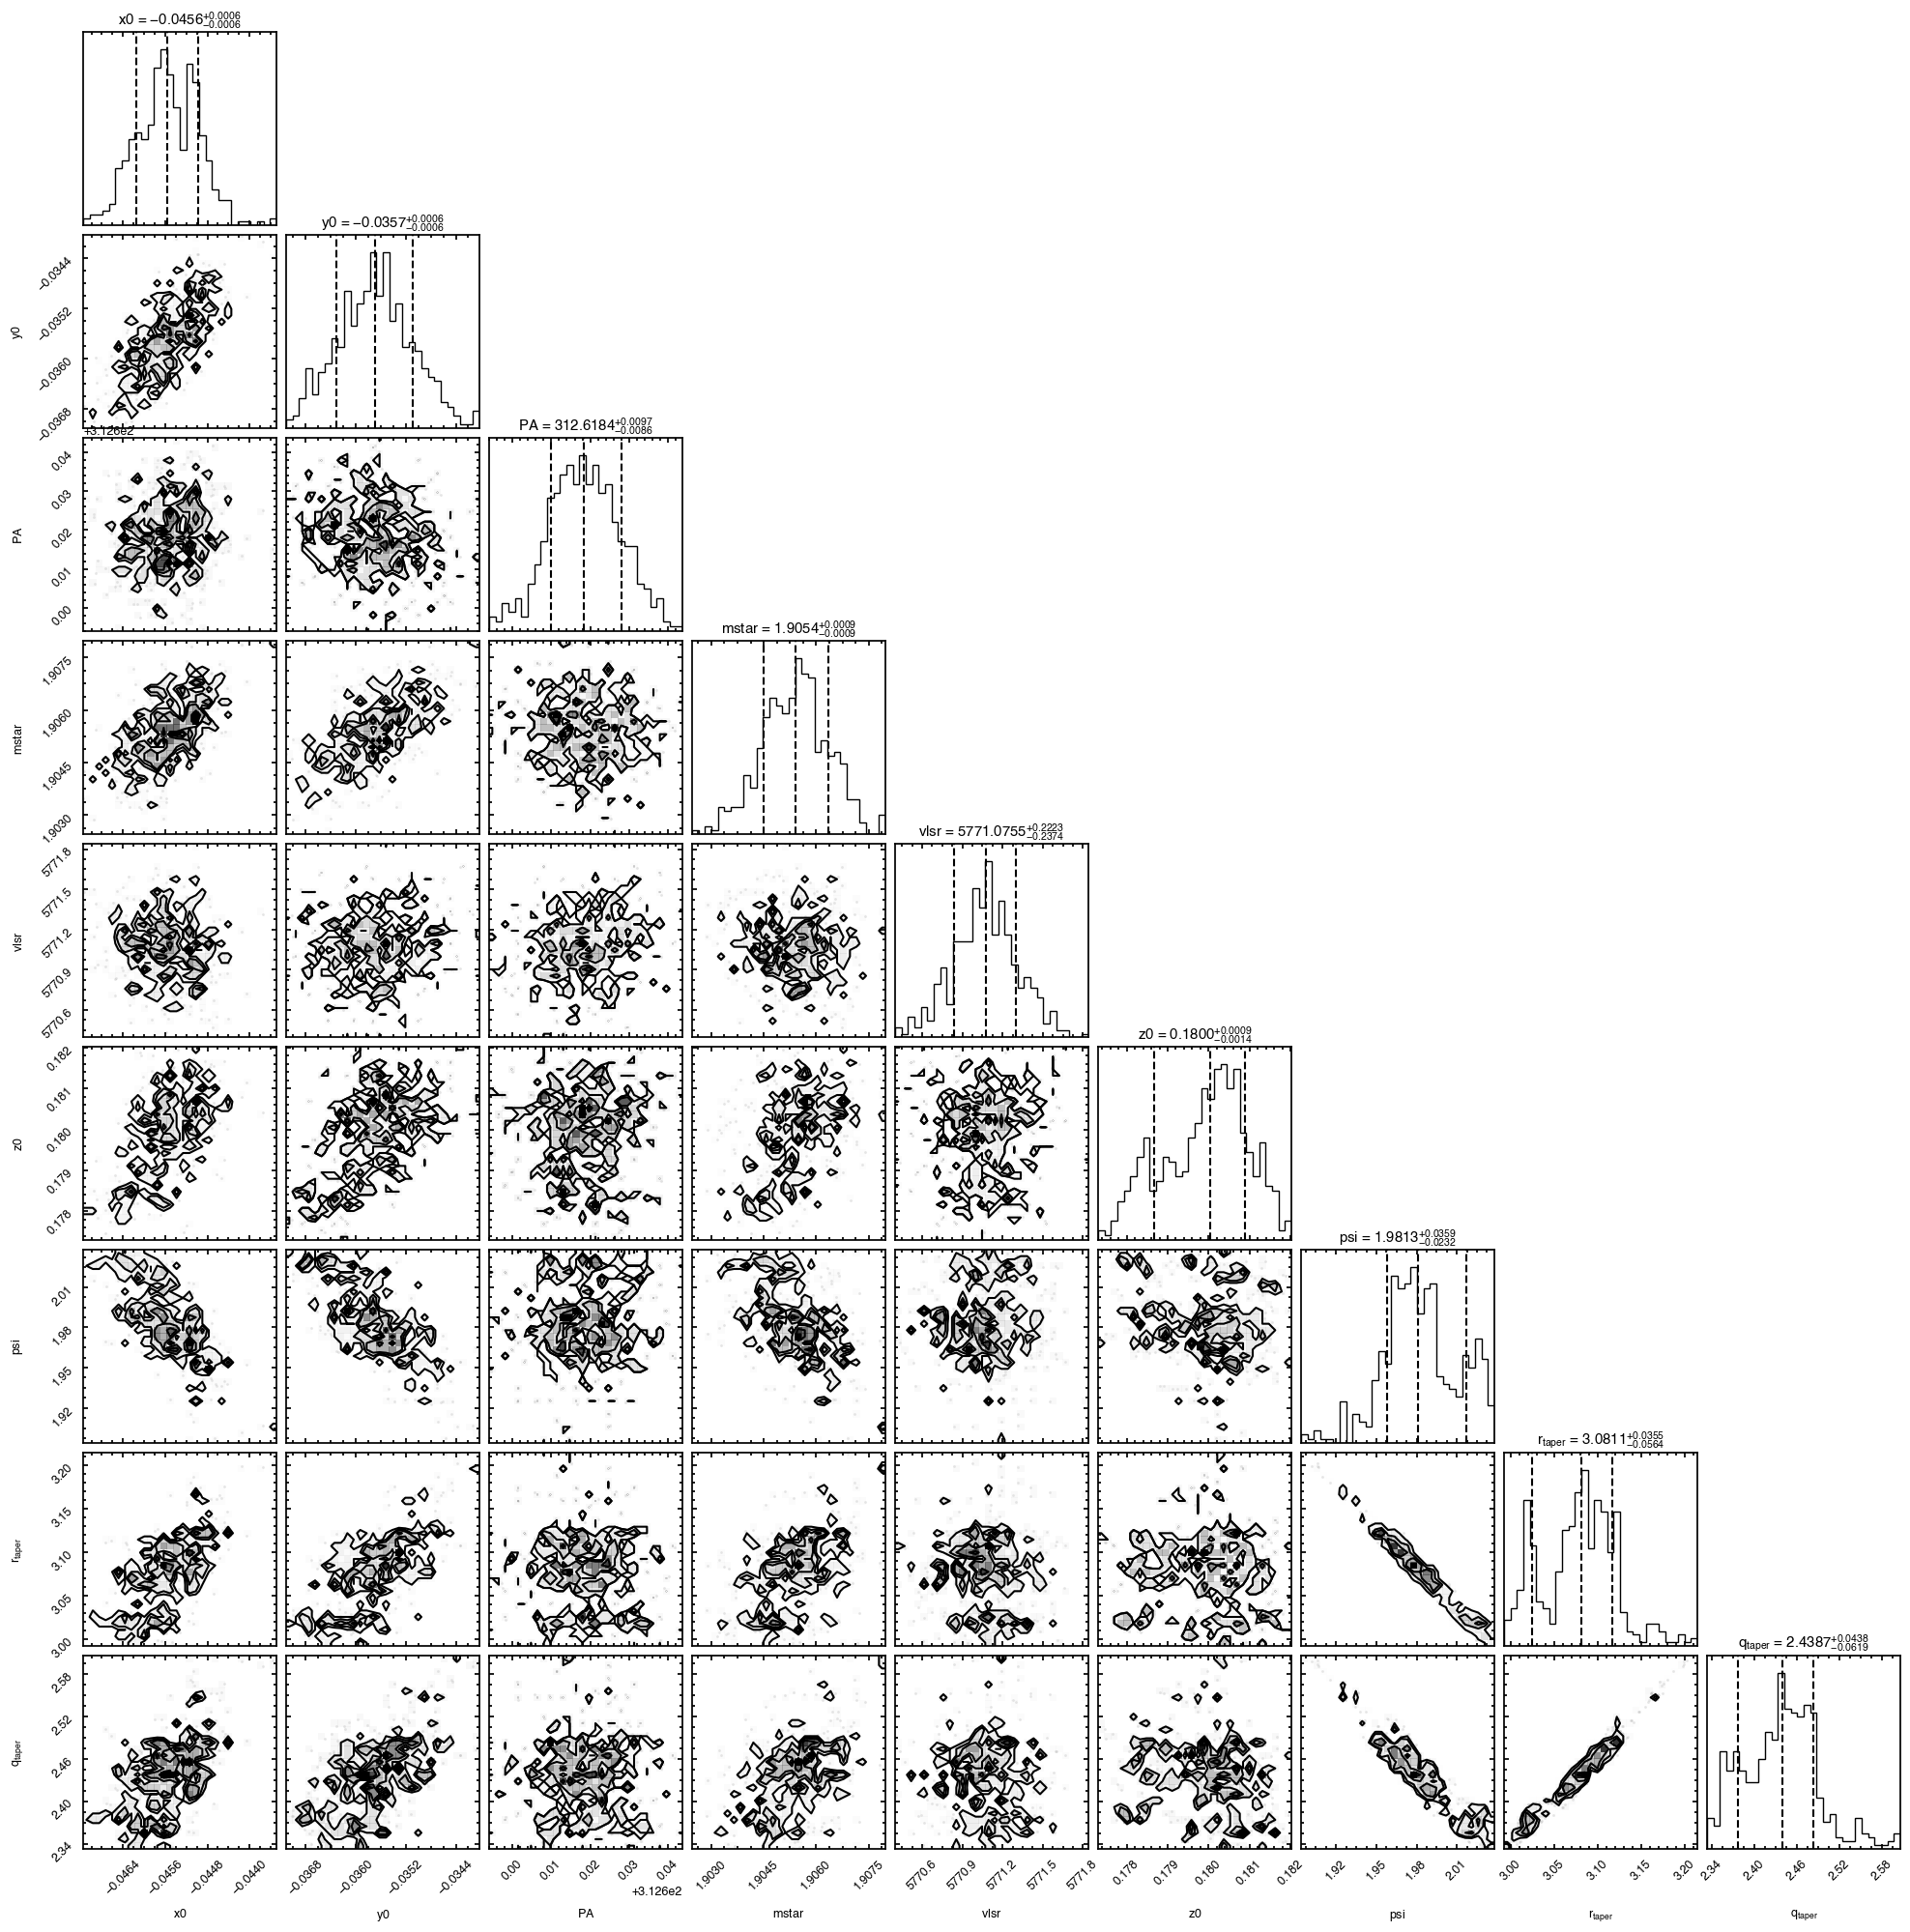

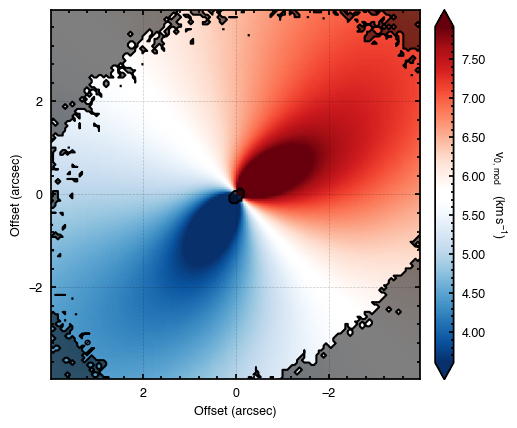

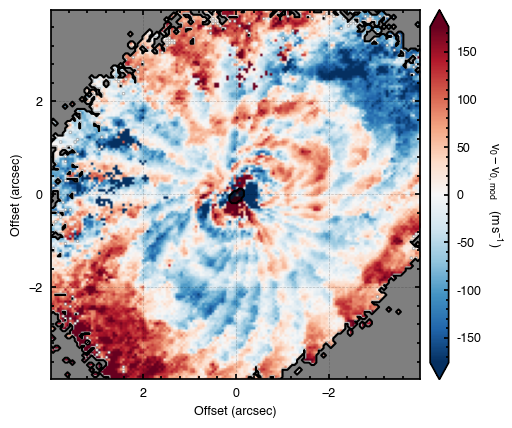

In [5]:
samples = cube.fit_map(
    p0=p0, params=params, optimize=True,
    nwalkers=1,    # numpyro: num_chains
    nburnin=500,   # numpyro: num_warmup
    nsteps=500,    # numpyro: num_samples
    mcmc='numpyro',
    mcmc_kwargs={
        'seed': 0,
        'progress': True,
        'max_tree_depth': 6,
    },
    plots=['walkers', 'corner', 'bestfit', 'residual'],
    returns=['samples', 'percentiles'],
)


## Wall time vs sample efficiency

NUTS is dramatically more sample-efficient than emcee. On the
validation fit recorded in ``REFACTORING_PLAN.md §5.1b``, ~500 numpyro
samples reach a posterior resolution comparable to ~128 000 emcee
samples — a 256× difference in raw sample count.

But each NUTS sample is *much* more expensive than each emcee step:

- emcee evaluates the log-probability once per walker per step.
  Recent fit_map speedups (commits ``f23cf29`` and ``867bc38``)
  compile that into a single XLA call that vmaps across walkers,
  taking a 32-walker step to ~12 µs per walker-eval (warm cache).
- NUTS samples by tracing a Hamiltonian trajectory through the
  posterior, doubling the trajectory length until it U-turns. On the
  9-parameter fit above, a typical iteration uses ~95 leapfrog steps
  (median), each requiring a gradient evaluation — roughly 2× the
  cost of a likelihood evaluation. So one NUTS sample does the work
  of ~190 emcee evaluations.

Multiply through: producing the same number of *effective* samples
takes numpyro ~190 / 256 ≈ 0.7× the *gradient* work emcee does. But
emcee's per-walker cost has dropped ~16× via vmap'd batch evaluation,
while numpyro can't share that optimisation (NUTS' tree extension is
per-chain, not per-walker). So in wall time, numpyro is currently
slower than emcee on most fits.

We have a tracking issue (see the GitHub repository) for further
numpyro performance work. The current recommendation is:

- For routine fits, stay on ``mcmc='emcee'`` — it's the default for
  exactly this reason.
- Use ``mcmc='numpyro'`` when sample efficiency is the bottleneck
  (e.g. each evaluation is very expensive, very long autocorrelation
  in emcee, or running on a GPU).


## Practical guidance

emcee remains the recommended default for routine fits — it's
embarrassingly parallel across walkers, has no JAX warm-up cost, and
the per-walker batch is compiled into a single XLA dispatch. Switch to
numpyro when one of these matches:

- The posterior is high-dimensional (≳ 8 free parameters) *and* you'd
  otherwise need a very long emcee chain to bring the autocorrelation
  time under control.
- You're running on a GPU. numpyro inherits JAX's device
  auto-detection, so a single ``mcmc='numpyro'`` call uses the GPU
  without further configuration.
- You want the same analytic gradient that ``optimize=True`` already
  uses internally to also drive the MCMC step.

The two backends are statistically equivalent on the validation fit
recorded in ``REFACTORING_PLAN.md §5.1b``: medians match within
0.2 σ on every parameter and posterior widths agree within 9 %.
